# EDA

## Importações

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

import sys
sys.path.append(f"../")
from Airflow_ETL.Pipelines.src.transacoes.criacao_clientes import gerar_clientes_pf, gerar_clientes_pj

In [7]:
pd.set_option('display.max_rows', 100)
pd.set_option('display.max_columns', 50)

## Funções Auxiliares

In [8]:
# Visualizar distribuições dos dados (histograma)
def visualizar_distribuicoes(df : pd.DataFrame):
    cols = df.columns    
    n_cols = 4
    if len(df.columns)%n_cols > 0:
        n_rows = len(df.columns)//n_cols + 1
    else:
        n_rows = len(df.columns)//n_cols
    fig, axs = plt.subplots(n_rows, n_cols, figsize=(n_cols*3, n_rows*3))
    axs = axs.flatten()

    for i in range(len(df.columns)):
        axs[i].hist(df[cols[i]], bins=100)
        axs[i].set_title(cols[i])

    plt.tight_layout()
    plt.show()
    
# Visualizar métricas R e P-Value entre as variáveis
def visualizar_correlacoes(df):
    df_copy = df.copy()

    # separar colunas
    num_cols = df_copy.select_dtypes(include=[np.number]).columns
    cat_cols = df_copy.select_dtypes(include=['object', 'category']).columns

    # criar dummies das categóricas
    if len(cat_cols) > 0:
        df_cat = pd.get_dummies(df_copy[cat_cols], prefix=cat_cols)
        df_vis = pd.concat([df_copy[num_cols], df_cat], axis=1)
    else:
        df_vis = df_copy[num_cols]

    cols = df_vis.columns
    n = len(cols)

    fig, axs = plt.subplots(n, n, figsize=(n*1.8, n*1.8))

    for i in range(n):
        for j in range(n):
            ax = axs[i, j]

            x = df_vis[cols[j]]
            y = df_vis[cols[i]]

            if i != j:
                ax.scatter(x, y, s=5)
                corr, p_value = stats.spearmanr(x, y)
                ax.set_title(f"r={corr:.2f} | p={p_value:.2g}", fontsize=7)
            else:
                ax.text(0.5, 0.5, cols[i], ha='center', va='center')

            ax.set_xticks([])
            ax.set_yticks([])

    plt.tight_layout()
    plt.show()

In [ ]:
clientes = gerar_clientes_pj(1000)
clientes.describe()

,idade_empresa,faturamento_anual,num_funcionarios,margem_lucro,alavancagem,historico_atraso,pd
count,1000.000000,1.000000e+03,1000.000000,1000.000000,1000.000000,1000.000000,1.000000e+03
mean,9.846000,4.378506e+06,34.311000,0.151347,0.506022,1.620000,1.904234e-01
std,4.736742,1.090804e+07,54.212944,0.092507,0.219999,1.876998,2.383875e-01
min,0.000000,2.153191e+04,1.000000,-0.074613,0.020078,0.000000,7.541230e-09
25%,7.000000,7.460453e+05,10.000000,0.077398,0.334939,0.000000,2.084985e-02
50%,10.000000,1.899617e+06,20.000000,0.147180,0.498496,1.000000,8.946487e-02
75%,13.000000,4.214903e+06,38.000000,0.224133,0.671929,2.000000,2.678250e-01
max,27.000000,2.400236e+08,785.000000,0.405366,0.995006,11.000000,9.991503e-01


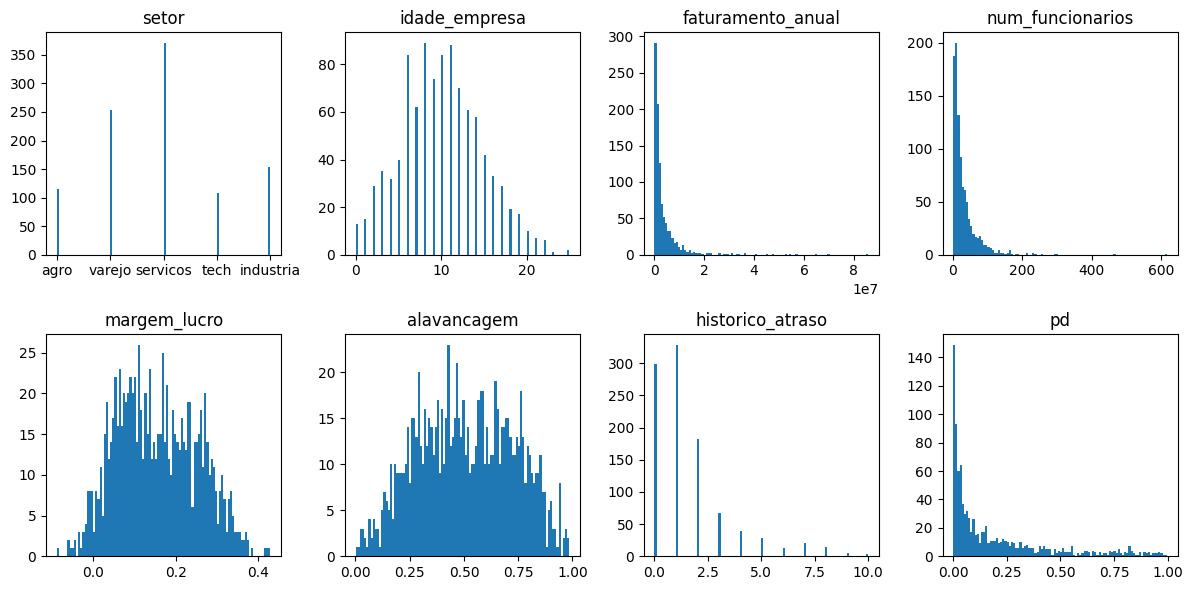

C:\Users\Fernando Luiz\AppData\Local\Temp\ipykernel_55832\1919706915.py:25: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = df_copy.select_dtypes(include=['object', 'category']).columns


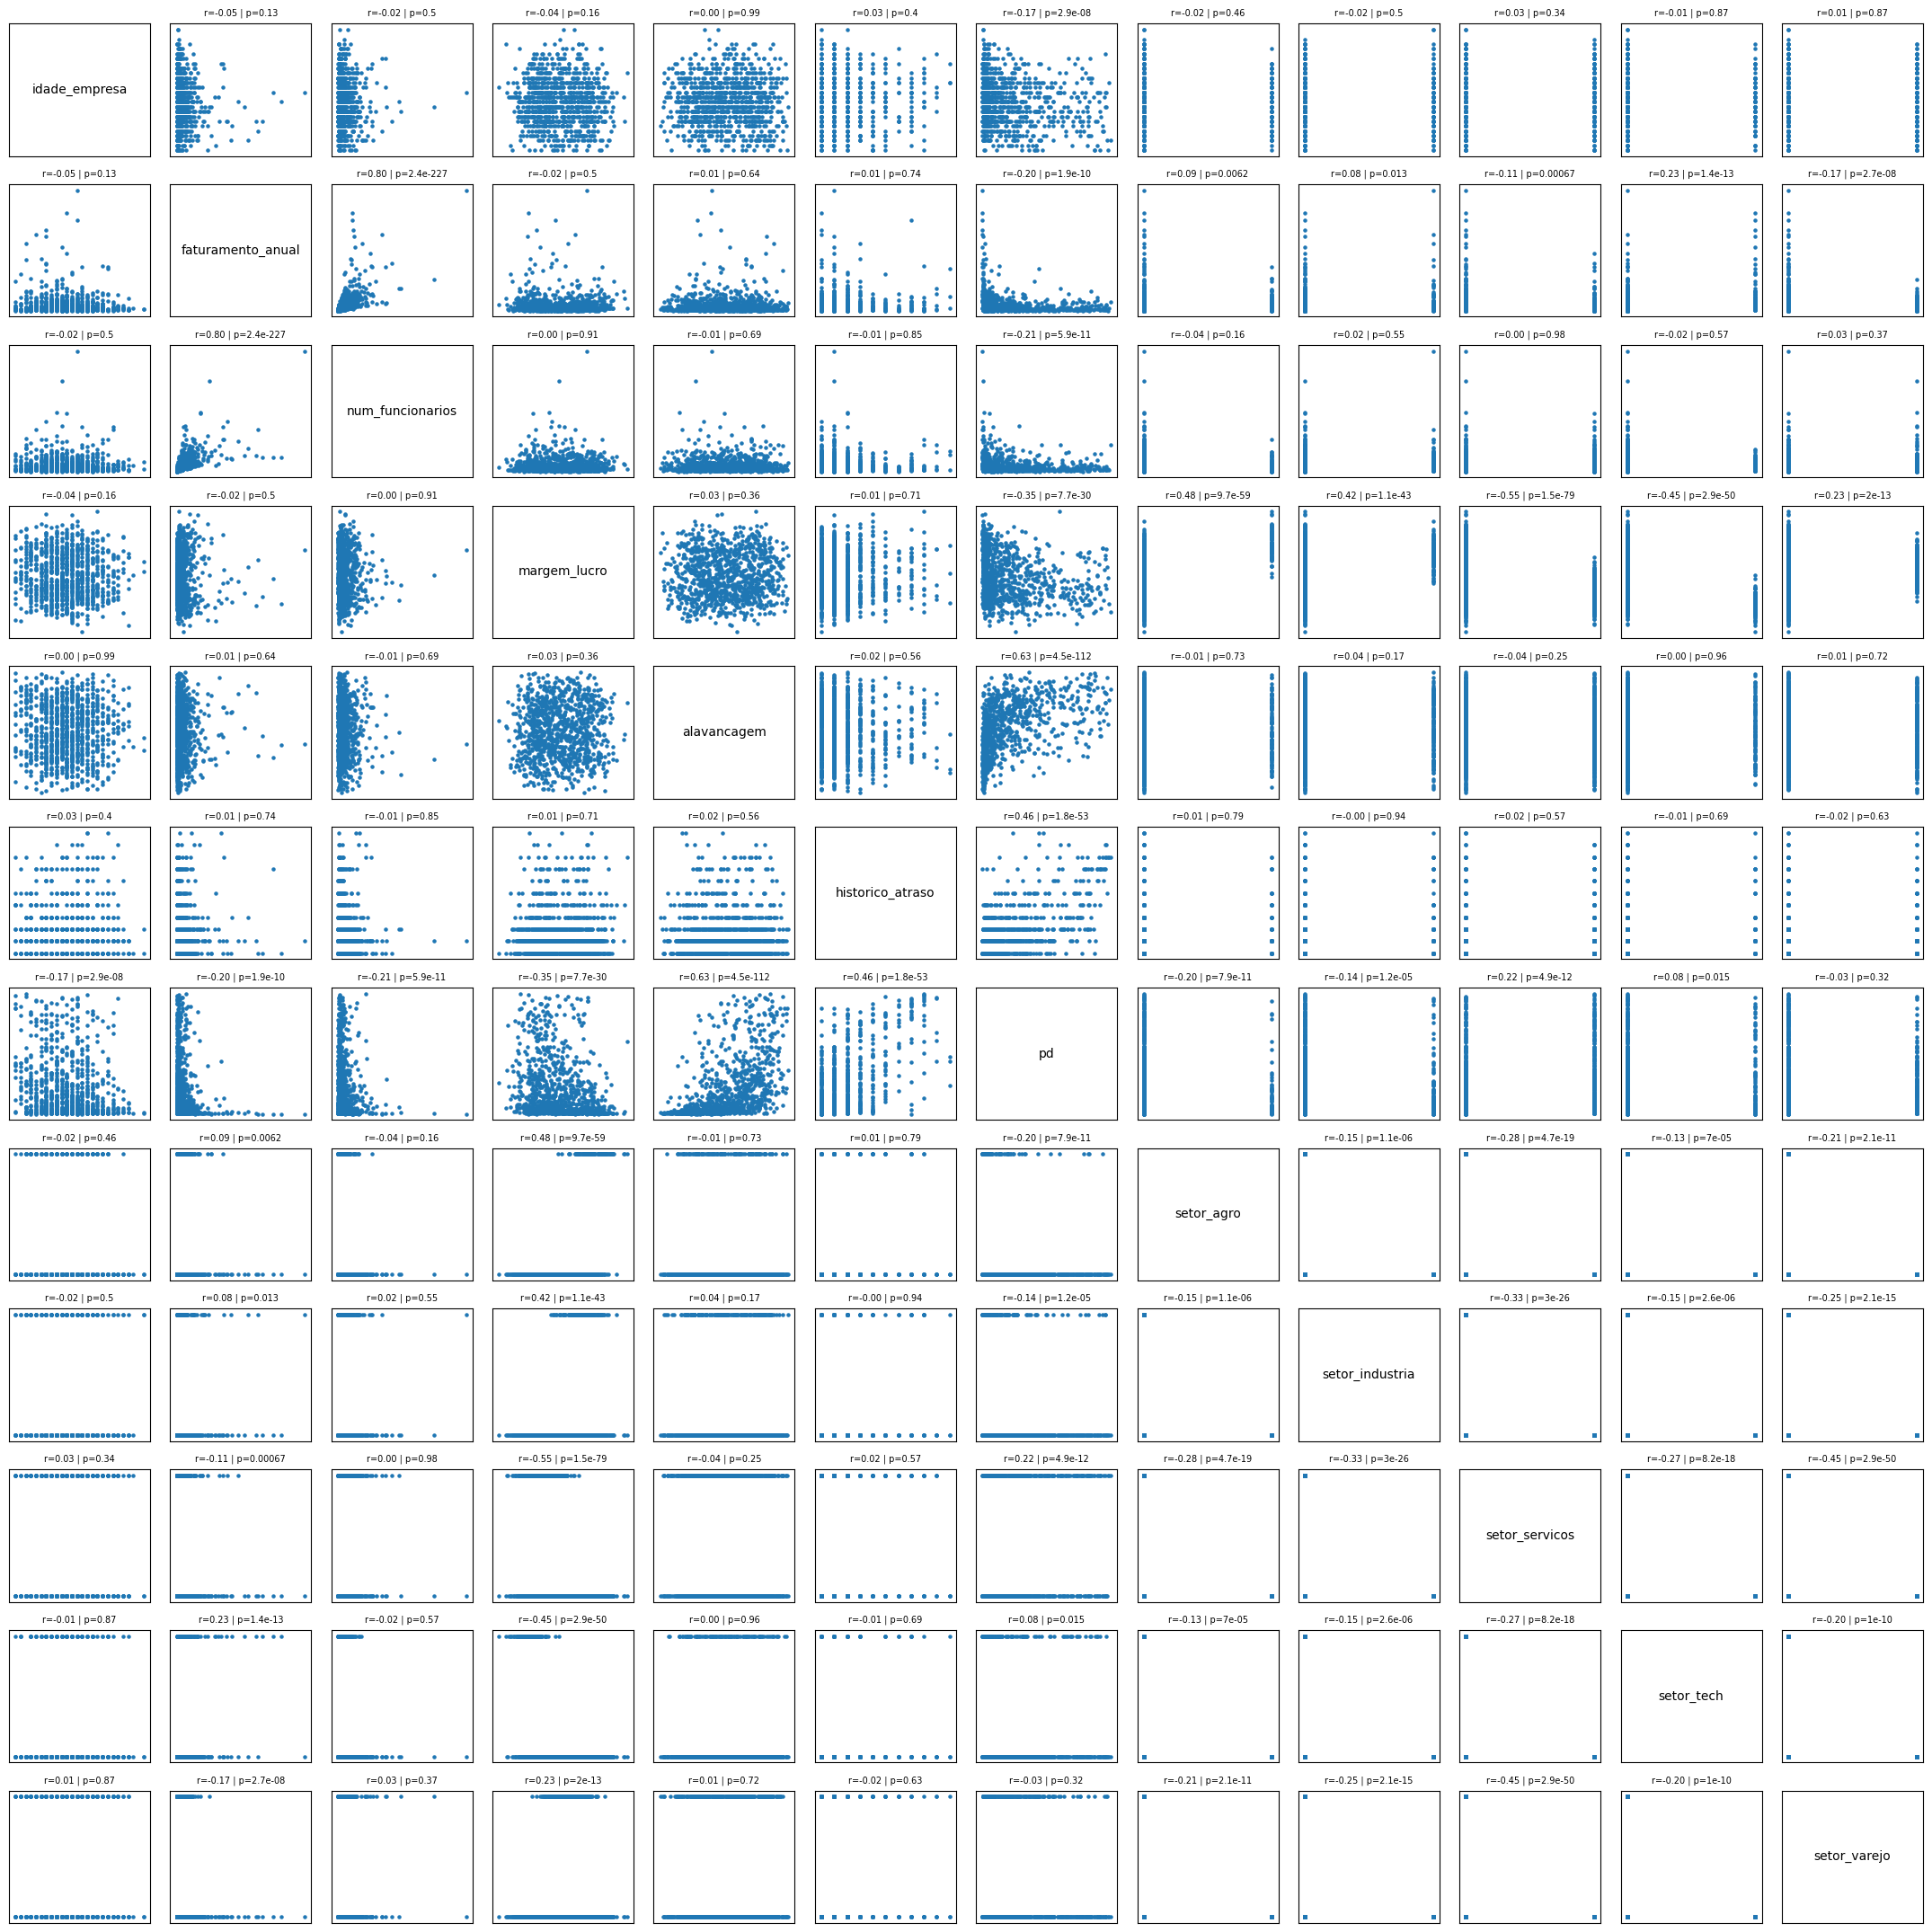

In [10]:
visualizar_distribuicoes(clientes)
visualizar_correlacoes(clientes)